# FinTech final assignment

The final assignment requires students to address a given problem starting from the assigned dataset, which contains information on default payments, demographic factors, credit data, history of payment, and bill statements of credit clients in Taiwan from April 2005 to September 2005.

What to do:
 - propose a ML cassifier exploiting a random forest and another with XGBoost
 - repeat the previous exercise AFTER exploiting a LAsso regression to reduce the number of features

At the end, you have to compare the two classifiers. Always choose the optimal hyperparameters. What are the most important drivers of the default? Is the dataset unbalanced? Is so, investigate the issue and propose a solution.

In [ ]:
# ── Colab / environment setup ─────────────────────────────────────────────────
import subprocess, sys

# Install missing packages (safe to run even if already installed)
pkgs = ["xgboost", "imbalanced-learn"]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

# Detect GPU availability
import importlib
try:
    import torch
    _has_gpu = torch.cuda.is_available()
except ImportError:
    try:
        import subprocess as _sp
        _result = _sp.run(["nvidia-smi"], capture_output=True)
        _has_gpu = _result.returncode == 0
    except Exception:
        _has_gpu = False

XGB_DEVICE = "cuda" if _has_gpu else "cpu"
XGB_TREE_METHOD = "hist"   # 'hist' works on both CPU and GPU in XGBoost >= 2.0

print(f"GPU available: {_has_gpu}")
print(f"XGBoost will use: device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}'")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("Dataset3.csv", sep=";")
df.rename(columns={"default.payment.next.month": "DEFAULT"}, inplace=True)
print(df.shape)
df.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Dataset Exploration

In [3]:
# Statistiche descrittive
df.info()
print("\nNull values:", df.isnull().sum().sum())
print("Dtypes:\n", df.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_0      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   PAY_3      30000 non-null  int64  
 9   PAY_4      30000 non-null  int64  
 10  PAY_5      30000 non-null  int64  
 11  PAY_6      30000 non-null  int64  
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   30000 non-null  float64
 20  PAY_AM

### 1. Class Imbalance (target variable)

No-Default / Default ratio: 3.52:1


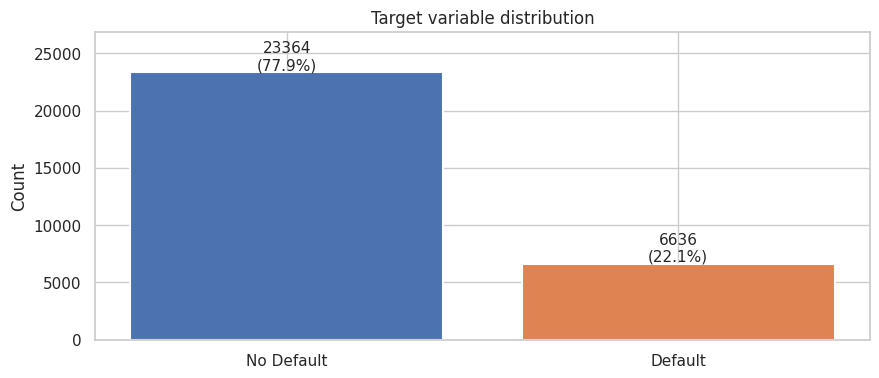

In [4]:
counts = df["DEFAULT"].value_counts()
labels = ["No Default", "Default"]
colors = ["#4C72B0", "#DD8452"]

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
# Bar chart
ax.bar(labels, counts.values, color=colors, edgecolor="white", linewidth=1.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=11)
ax.set_title("Target variable distribution")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)

print(f"No-Default / Default ratio: {counts[0]/counts[1]:.2f}:1")

### 2. Demographic Variables: Gender, Education, Marital Status

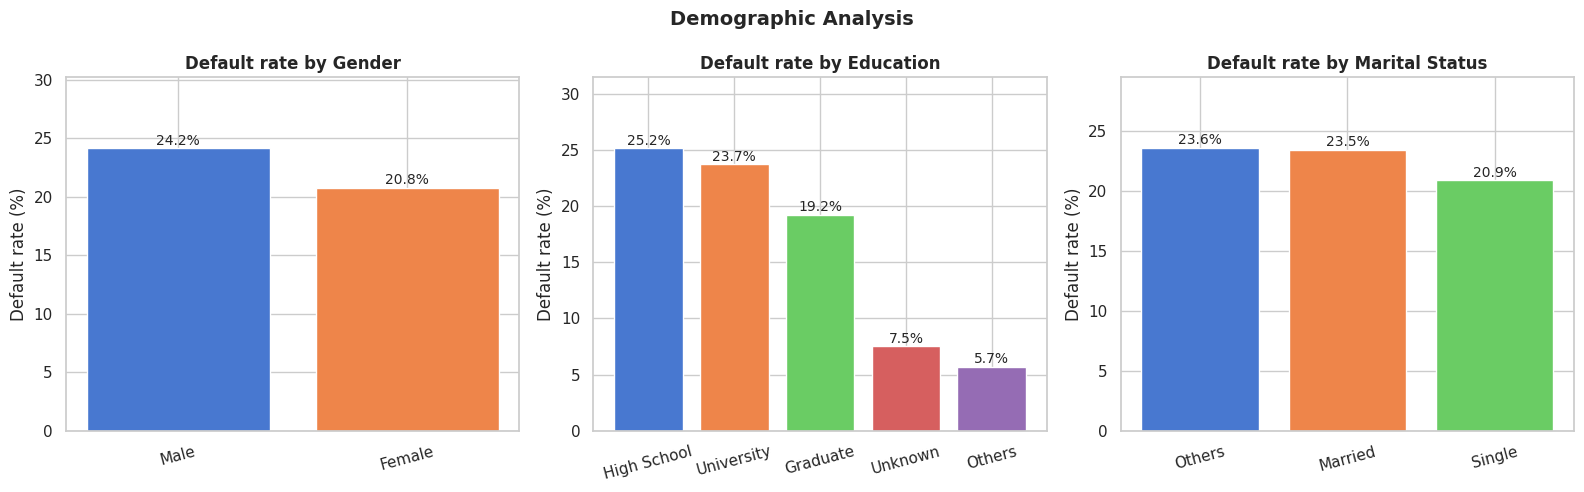

In [5]:
df_plot = df.copy()
df_plot["SEX"] = df_plot["SEX"].map({1: "Male", 2: "Female"})
df_plot["EDUCATION"] = df_plot["EDUCATION"].map({1: "Graduate", 2: "University", 3: "High School", 4: "Others", 5: "Unknown", 6: "Unknown"}).fillna("Unknown")
df_plot["MARRIAGE"] = df_plot["MARRIAGE"].map({1: "Married", 2: "Single", 3: "Others"}).fillna("Others")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes, ["SEX", "EDUCATION", "MARRIAGE"],
                          ["Default rate by Gender", "Default rate by Education", "Default rate by Marital Status"]):
    grp = df_plot.groupby(col)["DEFAULT"].mean().sort_values(ascending=False) * 100
    bars = ax.bar(grp.index, grp.values, color=sns.color_palette("muted", len(grp)), edgecolor="white")
    for bar, val in zip(bars, grp.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f"{val:.1f}%", ha="center", fontsize=10)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Default rate (%)")
    ax.set_ylim(0, grp.max() * 1.25)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Demographic Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

### 3. Age and Credit Limit Distributions

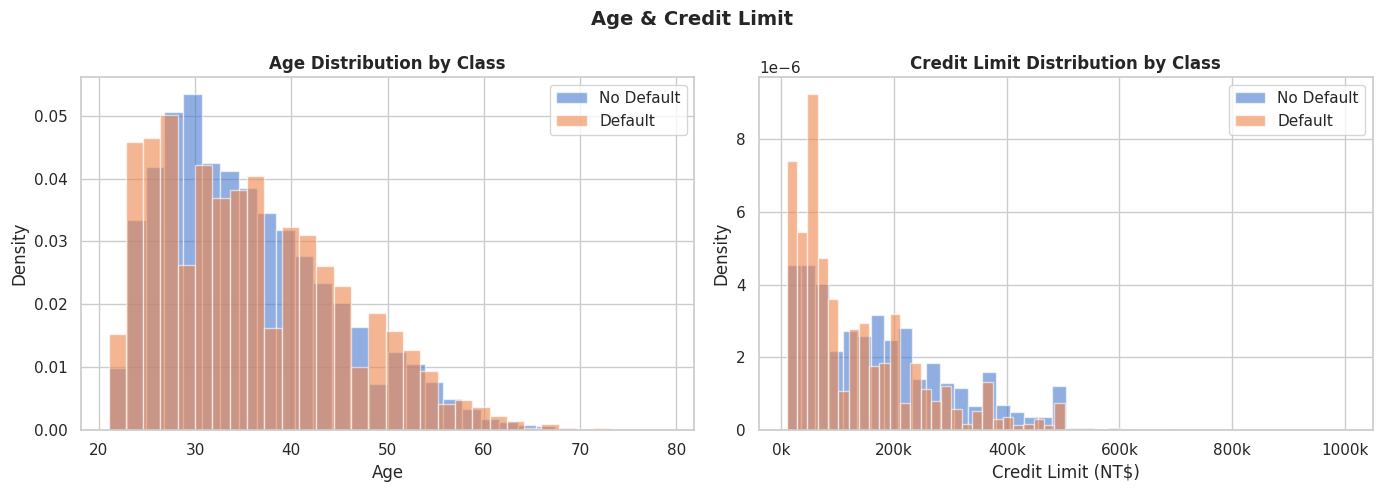

Mean age (No Default): 35.4
Mean age (Default): 35.7
Mean credit limit (No Default): 178100.0
Mean credit limit (Default): 130110.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age by class
for label, grp in df.groupby("DEFAULT"):
    axes[0].hist(grp["AGE"], bins=30, alpha=0.6, label=["No Default","Default"][label], density=True, edgecolor="white")
axes[0].set_title("Age Distribution by Class", fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density")
axes[0].legend()

# Credit limit by class
for label, grp in df.groupby("DEFAULT"):
    axes[1].hist(grp["LIMIT_BAL"], bins=40, alpha=0.6, label=["No Default","Default"][label], density=True, edgecolor="white")
axes[1].set_title("Credit Limit Distribution by Class", fontweight="bold")
axes[1].set_xlabel("Credit Limit (NT$)")
axes[1].set_ylabel("Density")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
axes[1].legend()

plt.suptitle("Age & Credit Limit", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_age_limit.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean age (No Default):", df[df.DEFAULT==0]["AGE"].mean().round(1))
print("Mean age (Default):", df[df.DEFAULT==1]["AGE"].mean().round(1))
print("Mean credit limit (No Default):", df[df.DEFAULT==0]["LIMIT_BAL"].mean().round(0))
print("Mean credit limit (Default):", df[df.DEFAULT==1]["LIMIT_BAL"].mean().round(0))

### 4. Payment History (PAY_0 … PAY_6): distribution and default rate

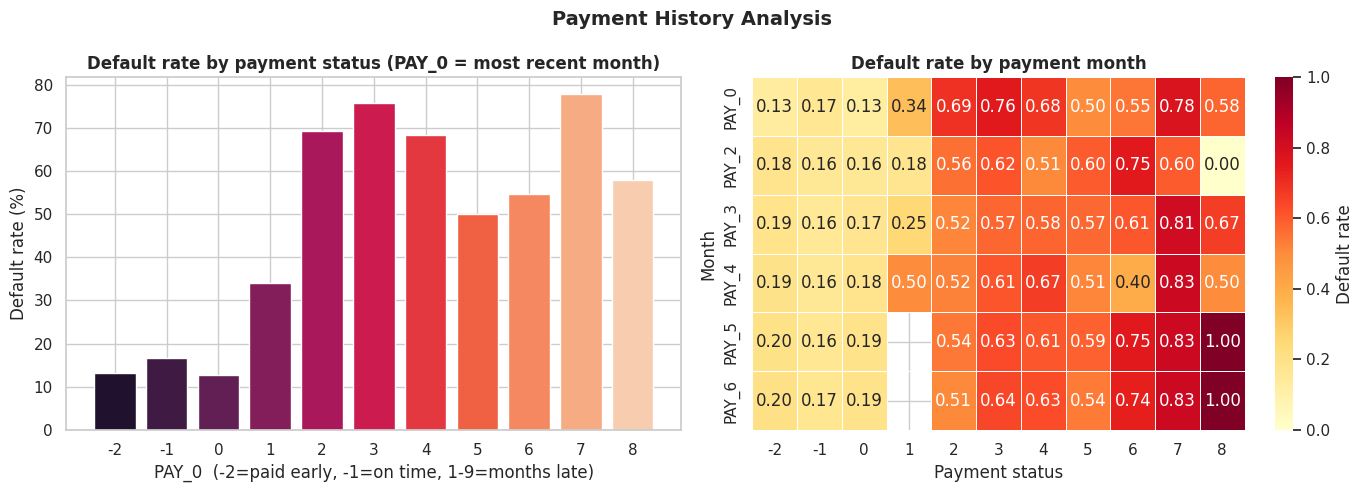

In [7]:
pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

pay0_rate = df.groupby("PAY_0")["DEFAULT"].mean().reset_index()
pay0_rate.columns = ["PAY_0", "Default Rate"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by PAY_0 value
axes[0].bar(pay0_rate["PAY_0"].astype(str), pay0_rate["Default Rate"]*100,
            color=sns.color_palette("rocket", len(pay0_rate)), edgecolor="white")
axes[0].set_title("Default rate by payment status (PAY_0 = most recent month)", fontweight="bold")
axes[0].set_xlabel("PAY_0  (-2=paid early, -1=on time, 1-9=months late)")
axes[0].set_ylabel("Default rate (%)")

# Heatmap default rate across all PAY_x columns
pivot = pd.DataFrame({col: df.groupby(col)["DEFAULT"].mean() for col in pay_cols})
sns.heatmap(pivot.T, ax=axes[1], cmap="YlOrRd", annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "Default rate"})
axes[1].set_title("Default rate by payment month", fontweight="bold")
axes[1].set_xlabel("Payment status")
axes[1].set_ylabel("Month")

plt.suptitle("Payment History Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_payment_history.png", dpi=150, bbox_inches="tight")
plt.show()

### 5. Temporal Trends: Bill Amounts and Payments Made

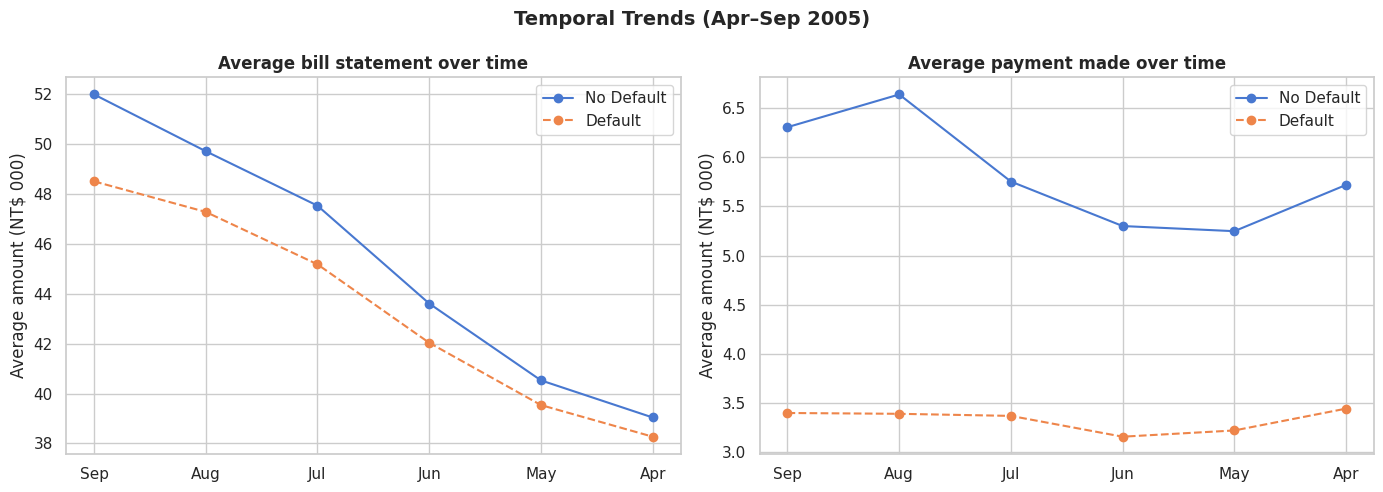

In [8]:
bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]
payamt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]
months = ["Sep","Aug","Jul","Jun","May","Apr"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, grp in df.groupby("DEFAULT"):
    name = ["No Default","Default"][label]
    ls = "--" if label == 1 else "-"
    axes[0].plot(months, grp[bill_cols].mean().values / 1000, marker="o", label=name, linestyle=ls)
    axes[1].plot(months, grp[payamt_cols].mean().values / 1000, marker="o", label=name, linestyle=ls)

axes[0].set_title("Average bill statement over time", fontweight="bold")
axes[0].set_ylabel("Average amount (NT$ 000)")
axes[0].legend()

axes[1].set_title("Average payment made over time", fontweight="bold")
axes[1].set_ylabel("Average amount (NT$ 000)")
axes[1].legend()

plt.suptitle("Temporal Trends (Apr–Sep 2005)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

### 6. Credit Utilization Ratio

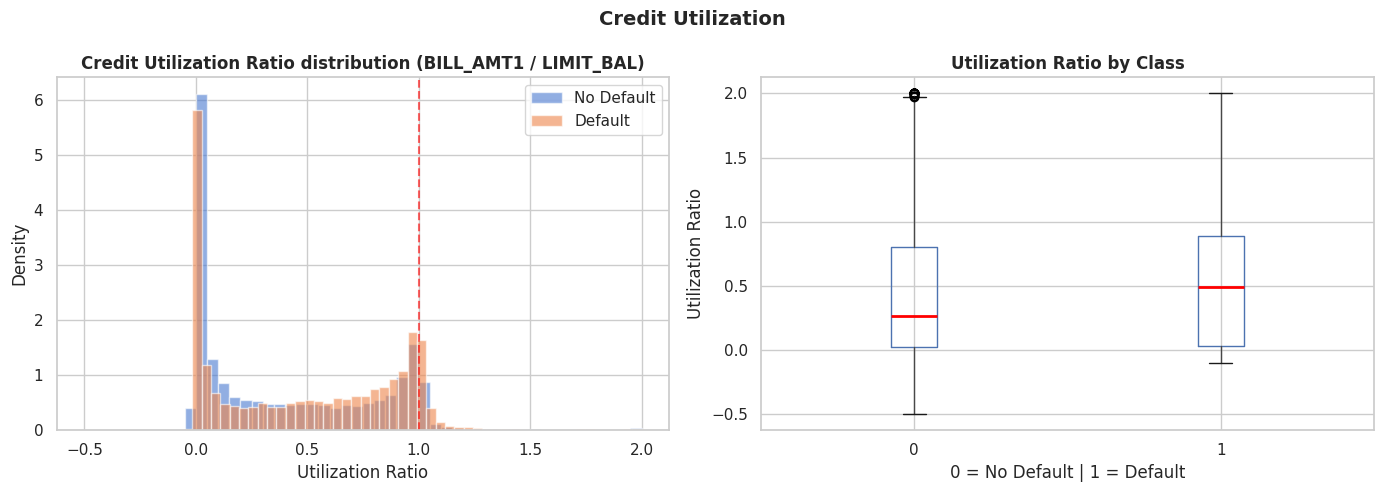

Median utilization (No Default): 0.267
Median utilization (Default): 0.493


In [9]:
df["UTIL_RATIO"] = df["BILL_AMT1"] / df["LIMIT_BAL"].replace(0, np.nan)
df["UTIL_RATIO"] = df["UTIL_RATIO"].clip(-0.5, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by class
for label, grp in df.groupby("DEFAULT"):
    axes[0].hist(grp["UTIL_RATIO"].dropna(), bins=50, alpha=0.6,
                 label=["No Default","Default"][label], density=True, edgecolor="white")
axes[0].set_title("Credit Utilization Ratio distribution (BILL_AMT1 / LIMIT_BAL)", fontweight="bold")
axes[0].set_xlabel("Utilization Ratio")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].axvline(1.0, color="red", linestyle="--", alpha=0.6, label="100% usage")

# Boxplot by class
df.boxplot(column="UTIL_RATIO", by="DEFAULT", ax=axes[1],
           boxprops=dict(color="#4C72B0"), medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Utilization Ratio by Class", fontweight="bold")
axes[1].set_xlabel("0 = No Default | 1 = Default")
axes[1].set_ylabel("Utilization Ratio")
plt.suptitle("")

plt.suptitle("Credit Utilization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_utilization.png", dpi=150, bbox_inches="tight")
plt.show()

print("Median utilization (No Default):", df[df.DEFAULT==0]["UTIL_RATIO"].median().round(3))
print("Median utilization (Default):", df[df.DEFAULT==1]["UTIL_RATIO"].median().round(3))

### 7. Correlation Matrix

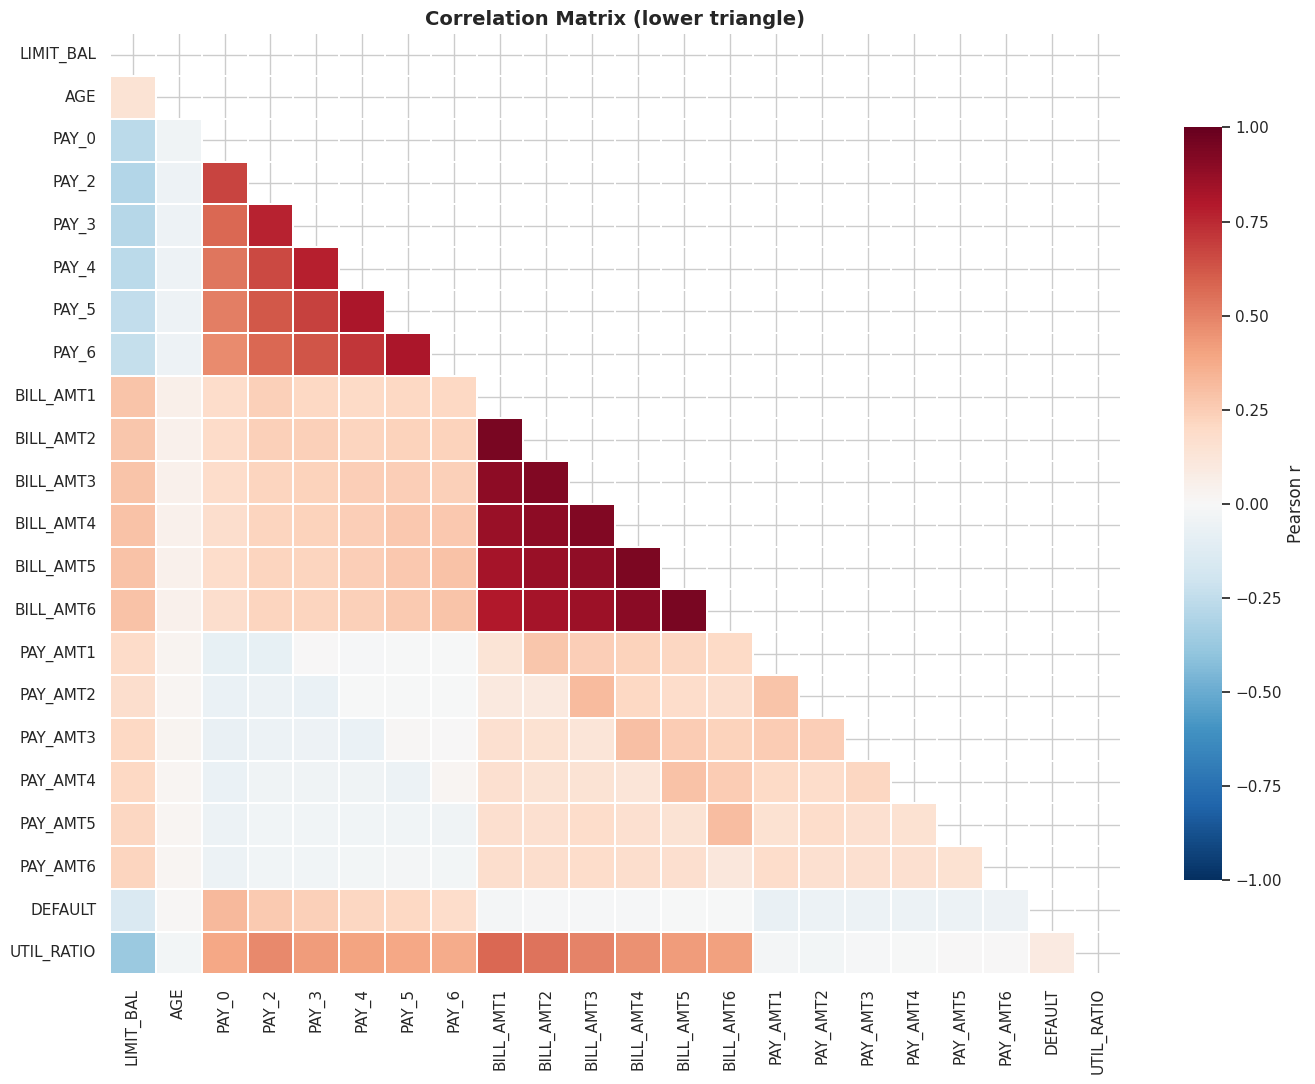

Top 10 features by absolute correlation with DEFAULT:
PAY_0         0.325
PAY_2         0.264
PAY_3         0.235
PAY_4         0.217
PAY_5         0.204
PAY_6         0.187
LIMIT_BAL     0.154
UTIL_RATIO    0.088
PAY_AMT1      0.073
PAY_AMT2      0.059
Name: DEFAULT, dtype: float64


In [10]:
num_cols = ["LIMIT_BAL","AGE","PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6",
            "BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6",
            "PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6","DEFAULT","UTIL_RATIO"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=False,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax.set_title("Correlation Matrix (lower triangle)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

top_corr = corr["DEFAULT"].drop("DEFAULT").abs().sort_values(ascending=False).head(10)
print("Top 10 features by absolute correlation with DEFAULT:")
print(top_corr.round(3))

### 8. Default Rate by Age Group and Credit Limit Band

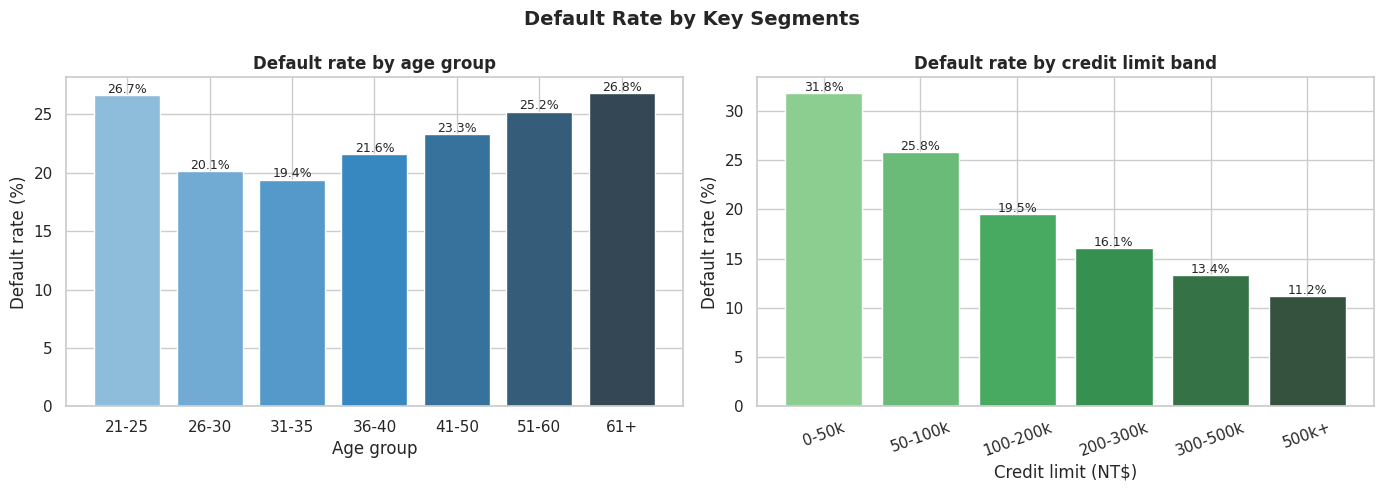

In [11]:
df["AGE_BIN"] = pd.cut(df["AGE"], bins=[20,25,30,35,40,50,60,80],
                       labels=["21-25","26-30","31-35","36-40","41-50","51-60","61+"])
df["LIMIT_BIN"] = pd.cut(df["LIMIT_BAL"], bins=[0,50000,100000,200000,300000,500000,1e6],
                         labels=["0-50k","50-100k","100-200k","200-300k","300-500k","500k+"])

age_rate = df.groupby("AGE_BIN", observed=True)["DEFAULT"].mean() * 100
lim_rate = df.groupby("LIMIT_BIN", observed=True)["DEFAULT"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_rate.index.astype(str), age_rate.values,
            color=sns.color_palette("Blues_d", len(age_rate)), edgecolor="white")
for i, v in enumerate(age_rate.values):
    axes[0].text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=9)
axes[0].set_title("Default rate by age group", fontweight="bold")
axes[0].set_ylabel("Default rate (%)")
axes[0].set_xlabel("Age group")

axes[1].bar(lim_rate.index.astype(str), lim_rate.values,
            color=sns.color_palette("Greens_d", len(lim_rate)), edgecolor="white")
for i, v in enumerate(lim_rate.values):
    axes[1].text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_title("Default rate by credit limit band", fontweight="bold")
axes[1].set_ylabel("Default rate (%)")
axes[1].set_xlabel("Credit limit (NT$)")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Default Rate by Key Segments", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_segments.png", dpi=150, bbox_inches="tight")
plt.show()

## Random Forest Classifier

### 1. Data Preparation & Train/Test Split

In [12]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Drop ID and engineered bin columns; keep original features
drop_cols = ["ID", "AGE_BIN", "LIMIT_BIN", "UTIL_RATIO"]
feature_cols = [c for c in df.columns if c not in drop_cols + ["DEFAULT"]]

X = df[feature_cols]
y = df["DEFAULT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Class balance in train — 0: {(y_train==0).sum():,}  1: {(y_train==1).sum():,}")

Train size: 24,000  |  Test size: 6,000
Class balance in train — 0: 18,691  1: 5,309


### 2. Handling Class Imbalance with SMOTE

The dataset is imbalanced (~3.5:1). We apply **SMOTE** (Synthetic Minority Over-sampling Technique) exclusively on the **training set** to avoid data leakage into the test set.

In [ ]:
from imblearn.over_sampling import SMOTE

# sampling_strategy=1.0 → full 1:1 balance between classes
smote = SMOTE(random_state=42, sampling_strategy=1.0)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — 0: {(y_train==0).sum():,}  1: {(y_train==1).sum():,}  ratio: {(y_train==0).sum()/(y_train==1).sum():.2f}:1")
print(f"After  SMOTE — 0: {(y_train_bal==0).sum():,}  1: {(y_train_bal==1).sum():,}  ratio: {(y_train_bal==0).sum()/(y_train_bal==1).sum():.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(axes,
                              [y_train.value_counts(), y_train_bal.value_counts()],
                              ["Before SMOTE", "After SMOTE"]):
    ax.bar(["No Default", "Default"], [counts[0], counts[1]],
           color=["#4C72B0", "#DD8452"], edgecolor="white")
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=11)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(counts[0], counts[1]) * 1.15)

plt.suptitle("Training Set Class Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2. Hyperparameter Tuning: Two-Stage Approach

**Stage 1 — RandomizedSearchCV**: broad exploration of the parameter space to identify promising regions.  
**Stage 2 — GridSearchCV**: exhaustive search on a narrow grid centered around the best values found in stage 1.

In [14]:
from sklearn.model_selection import GridSearchCV

# --- Stage 1: broad random search (3-fold CV, 15 iterations) ---
param_dist = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
random_search.fit(X_train_bal, y_train_bal)
bp = random_search.best_params_
print("Stage 1 best params:", bp)
print(f"Stage 1 best CV ROC-AUC: {random_search.best_score_:.4f}")

# --- Stage 2: narrow GridSearchCV (±1 step around best values, 3-fold CV) ---
def neighbours(val, step, n=1, min_val=1):
    return sorted({max(min_val, val + i * step) for i in range(-n, n + 1)})

fine_grid = {
    "n_estimators":      neighbours(bp["n_estimators"],      50),
    "max_depth":         neighbours(bp["max_depth"],          2, min_val=3),
    "min_samples_split": neighbours(bp["min_samples_split"],  2, min_val=2),
    "min_samples_leaf":  neighbours(bp["min_samples_leaf"],   1, min_val=1),
    "max_features":      [bp["max_features"]],
}
n_combos = 1
for v in fine_grid.values():
    n_combos *= len(v)
print(f"\nStage 2 grid → {n_combos} combinations × 3 folds = {n_combos*3} fits")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=fine_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_bal, y_train_bal)
print("\nStage 2 best params:", grid_search.best_params_)
print(f"Stage 2 best CV ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Improvement over stage 1: {(grid_search.best_score_ - random_search.best_score_)*100:+.2f}pp")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Stage 1 best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Stage 1 best CV ROC-AUC: 0.8559

Stage 2 grid → 36 combinations × 3 folds = 108 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Stage 2 best params: {'max_depth': 22, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}
Stage 2 best CV ROC-AUC: 0.8574
Improvement over stage 1: +0.15pp


### 3. Evaluation on Test Set

              precision    recall  f1-score   support

  No Default       0.85      0.92      0.88      4673
     Default       0.59      0.42      0.49      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.67      0.69      6000
weighted avg       0.79      0.81      0.79      6000

Test ROC-AUC: 0.7628


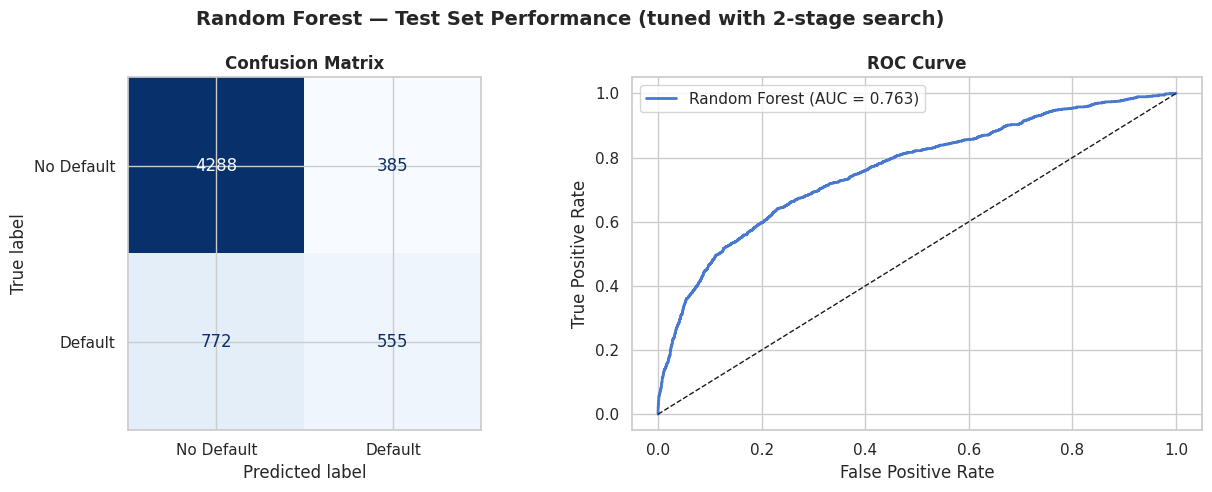

In [15]:
best_rf = grid_search.best_estimator_   # final model from stage-2 GridSearchCV
y_pred  = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Default","Default"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["No Default","Default"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, label=f"Random Forest (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend()

plt.suptitle("Random Forest — Test Set Performance (tuned with 2-stage search)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_rf_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

### 4. Feature Importance

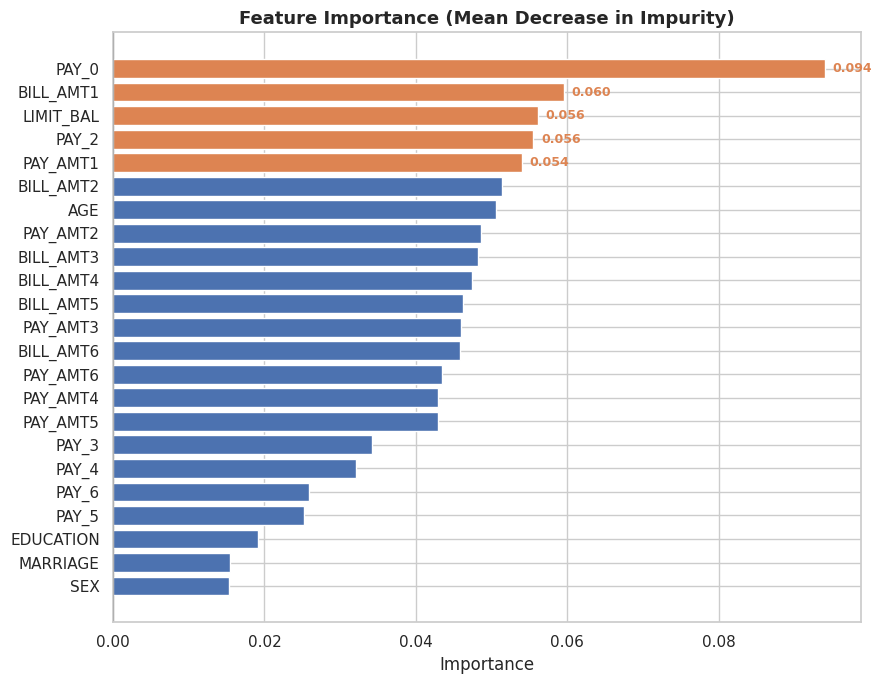


Top 5 most important features:
PAY_0        0.0940
BILL_AMT1    0.0596
LIMIT_BAL    0.0561
PAY_2        0.0555
PAY_AMT1     0.0540
dtype: float64


In [16]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#DD8452" if v >= importances.nlargest(5).min() else "#4C72B0" for v in importances]
ax.barh(importances.index, importances.values, color=colors, edgecolor="white")
ax.set_title("Feature Importance (Mean Decrease in Impurity)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
ax.axvline(0, color="black", linewidth=0.8)

# Highlight top-5 label
for i, (name, val) in enumerate(importances.items()):
    if val >= importances.nlargest(5).min():
        ax.text(val + 0.001, i, f"{val:.3f}", va="center", fontsize=9, color="#DD8452", fontweight="bold")

plt.tight_layout()
plt.savefig("plot_rf_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
print(importances.nlargest(5).round(4))

## XGBoost Classifier

### 1. Hyperparameter Tuning: Two-Stage Approach

Same SMOTE-balanced training set as RF. XGBoost natively handles early stopping to avoid overfitting.

In [ ]:
from xgboost import XGBClassifier

# --- Stage 1: broad random search ---
xgb_param_dist = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [3, 5, 7, 9],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric="auc", verbosity=0,
                  tree_method=XGB_TREE_METHOD, device=XGB_DEVICE),
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=1 if _has_gpu else -1,   # GPU models can't run in parallel workers
    verbose=1,
)
xgb_random.fit(X_train_bal, y_train_bal)
bp_xgb = xgb_random.best_params_
print("Stage 1 best params:", bp_xgb)
print(f"Stage 1 best CV ROC-AUC: {xgb_random.best_score_:.4f}")

# --- Stage 2: narrow GridSearchCV ---
def neighbours(val, step, n=1, min_val=1):
    return sorted({max(min_val, val + i * step) for i in range(-n, n + 1)})

xgb_fine_grid = {
    "n_estimators":     neighbours(bp_xgb["n_estimators"],    50),
    "max_depth":        neighbours(bp_xgb["max_depth"],         1, min_val=2),
    "learning_rate":    [bp_xgb["learning_rate"]],
    "subsample":        [bp_xgb["subsample"]],
    "colsample_bytree": [bp_xgb["colsample_bytree"]],
    "min_child_weight": neighbours(bp_xgb["min_child_weight"],  1, min_val=1),
}
n_combos = 1
for v in xgb_fine_grid.values():
    n_combos *= len(v)
print(f"\nStage 2 grid → {n_combos} combinations × 3 folds = {n_combos*3} fits")

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric="auc", verbosity=0,
                  tree_method=XGB_TREE_METHOD, device=XGB_DEVICE),
    param_grid=xgb_fine_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1 if _has_gpu else -1,
    verbose=1,
)
xgb_grid.fit(X_train_bal, y_train_bal)
print("\nStage 2 best params:", xgb_grid.best_params_)
print(f"Stage 2 best CV ROC-AUC: {xgb_grid.best_score_:.4f}")
print(f"Improvement over stage 1: {(xgb_grid.best_score_ - xgb_random.best_score_)*100:+.2f}pp")

### 2. Evaluation on Test Set

              precision    recall  f1-score   support

  No Default       0.84      0.91      0.88      4673
     Default       0.56      0.40      0.47      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.66      0.67      6000
weighted avg       0.78      0.80      0.79      6000

Test ROC-AUC: 0.7472


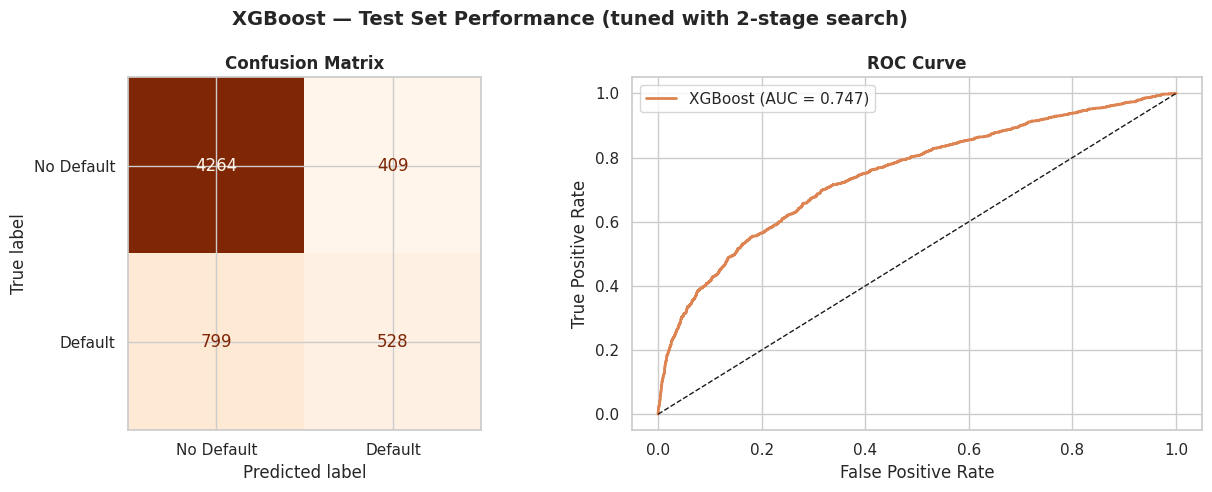

In [18]:
best_xgb = xgb_grid.best_estimator_
y_pred_xgb  = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=["No Default", "Default"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb),
                       display_labels=["No Default", "Default"]).plot(ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title("Confusion Matrix", fontweight="bold")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, lw=2, color="#DD8452",
             label=f"XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend()

plt.suptitle("XGBoost — Test Set Performance (tuned with 2-stage search)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_xgb_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

### 3. Feature Importance

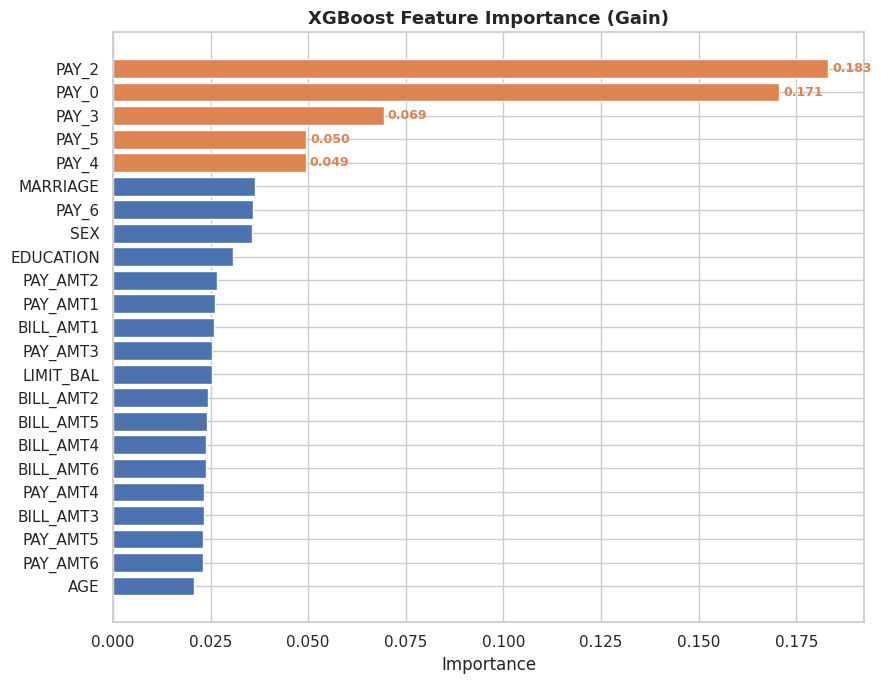


Top 5 most important features:
PAY_2    0.1832
PAY_0    0.1707
PAY_3    0.0694
PAY_5    0.0495
PAY_4    0.0494
dtype: float32


In [19]:
imp_xgb = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#DD8452" if v >= imp_xgb.nlargest(5).min() else "#4C72B0" for v in imp_xgb]
ax.barh(imp_xgb.index, imp_xgb.values, color=colors, edgecolor="white")
ax.set_title("XGBoost Feature Importance (Gain)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")

for i, (name, val) in enumerate(imp_xgb.items()):
    if val >= imp_xgb.nlargest(5).min():
        ax.text(val + 0.001, i, f"{val:.3f}", va="center", fontsize=9, color="#DD8452", fontweight="bold")

plt.tight_layout()
plt.savefig("plot_xgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
print(imp_xgb.nlargest(5).round(4))

## Model Comparison: Random Forest vs XGBoost

In [20]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def metrics(y_true, y_pred, y_proba, name):
    return {
        "Model":     name,
        "ROC-AUC":   round(roc_auc_score(y_true, y_proba), 4),
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "F1 (Default)": round(f1_score(y_true, y_pred), 4),
        "Precision (Default)": round(precision_score(y_true, y_pred), 4),
        "Recall (Default)":    round(recall_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    metrics(y_test, y_pred,     y_proba,     "Random Forest"),
    metrics(y_test, y_pred_xgb, y_proba_xgb, "XGBoost"),
]).set_index("Model")

display(results.style.highlight_max(axis=0, color="#c6efce").format("{:.4f}"))


,ROC-AUC,Accuracy,F1 (Default),Precision (Default),Recall (Default)
Model,,,,,
Random Forest,0.7628,0.8072,0.4896,0.5904,0.4182
XGBoost,0.7472,0.7987,0.4664,0.5635,0.3979


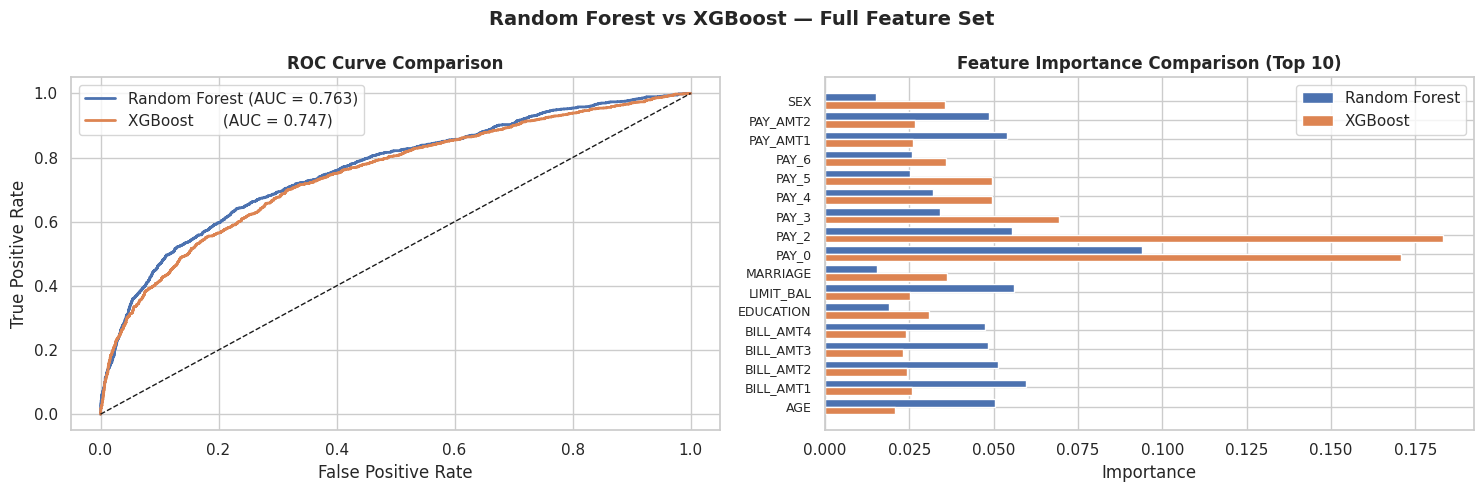

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Overlaid ROC curves ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba)
fpr_xgb2, tpr_xgb2, _ = roc_curve(y_test, y_proba_xgb)

axes[0].plot(fpr_rf,   tpr_rf,   lw=2, color="#4C72B0",
             label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba):.3f})")
axes[0].plot(fpr_xgb2, tpr_xgb2, lw=2, color="#DD8452",
             label=f"XGBoost      (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Comparison", fontweight="bold")
axes[0].legend()

# --- Side-by-side feature importance (top 10 union) ---
top_rf  = importances.nlargest(10)
top_xgb2 = imp_xgb.nlargest(10)
all_feats = sorted(set(top_rf.index) | set(top_xgb2.index))
rf_vals  = [importances.get(f, 0)  for f in all_feats]
xgb_vals = [imp_xgb.get(f, 0) for f in all_feats]

y_pos = list(range(len(all_feats)))
axes[1].barh([p + 0.2 for p in y_pos], rf_vals,  height=0.4, color="#4C72B0", label="Random Forest")
axes[1].barh([p - 0.2 for p in y_pos], xgb_vals, height=0.4, color="#DD8452", label="XGBoost")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(all_feats, fontsize=9)
axes[1].set_xlabel("Importance")
axes[1].set_title("Feature Importance Comparison (Top 10)", fontweight="bold")
axes[1].legend()

plt.suptitle("Random Forest vs XGBoost — Full Feature Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_comparison_full.png", dpi=150, bbox_inches="tight")
plt.show()

## Lasso-Based Feature Selection

We use **Lasso logistic regression** (L1 penalty) to identify the most relevant features. Features whose coefficient is shrunk to exactly zero are discarded. We then retrain both classifiers on the reduced feature set and compare performance.

### 1. Lasso Logistic Regression — Optimal C via Cross-Validation

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

# Lasso needs standardised features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

# Small C values → strong L1 regularization → more features zeroed out
lasso = LogisticRegressionCV(
    Cs=[0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
    cv=3,
    penalty="l1",
    solver="saga",
    scoring="roc_auc",
    max_iter=2000,
    random_state=42,
    n_jobs=-1,
)
lasso.fit(X_train_sc, y_train_bal)

coef = pd.Series(lasso.coef_[0], index=feature_cols)
selected = coef[coef != 0].index.tolist()
zeroed   = coef[coef == 0].index.tolist()

print(f"Optimal C: {lasso.C_[0]:.5f}")
print(f"Features kept   ({len(selected)}): {selected}")
print(f"Features zeroed ({len(zeroed)}):  {zeroed}")

# Plot coefficients
coef_sorted = coef.sort_values()
colors = ["#DD8452" if v != 0 else "#cccccc" for v in coef_sorted]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(coef_sorted.index, coef_sorted.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Lasso Logistic Regression Coefficients\n(grey = zeroed out)", fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.savefig("plot_lasso_coef.png", dpi=150, bbox_inches="tight")
plt.show()

### 2. RF and XGBoost on Lasso-Selected Features

In [ ]:
# Reduced datasets (unscaled — trees don't need scaling)
X_train_red = X_train_bal[selected]
X_test_red  = X_test[selected]

print(f"Reduced feature set ({len(selected)} features): {selected}")

# --- RF on reduced features ---
rf_red = RandomForestClassifier(**grid_search.best_params_, random_state=42, n_jobs=-1)
rf_red.fit(X_train_red, y_train_bal)
y_pred_rf_red   = rf_red.predict(X_test_red)
y_proba_rf_red  = rf_red.predict_proba(X_test_red)[:, 1]

# --- XGBoost on reduced features ---
xgb_red = XGBClassifier(**xgb_grid.best_params_, random_state=42, n_jobs=-1,
                         eval_metric="auc", verbosity=0,
                         tree_method=XGB_TREE_METHOD, device=XGB_DEVICE)
xgb_red.fit(X_train_red, y_train_bal)
y_pred_xgb_red  = xgb_red.predict(X_test_red)
y_proba_xgb_red = xgb_red.predict_proba(X_test_red)[:, 1]

print("\n— Random Forest (reduced) —")
print(classification_report(y_test, y_pred_rf_red, target_names=["No Default","Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf_red):.4f}")

print("\n— XGBoost (reduced) —")
print(classification_report(y_test, y_pred_xgb_red, target_names=["No Default","Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb_red):.4f}")

### 3. Final Comparison: Full Features vs Lasso-Reduced Features

,ROC-AUC,Accuracy,F1 (Default),Precision (Default),Recall (Default)
Model,,,,,
RF — Full features,0.7628,0.8072,0.4896,0.5904,0.4182
RF — Lasso reduced,0.7628,0.8072,0.4896,0.5904,0.4182
XGB — Full features,0.7472,0.7987,0.4664,0.5635,0.3979
XGB — Lasso reduced,0.7472,0.7987,0.4664,0.5635,0.3979


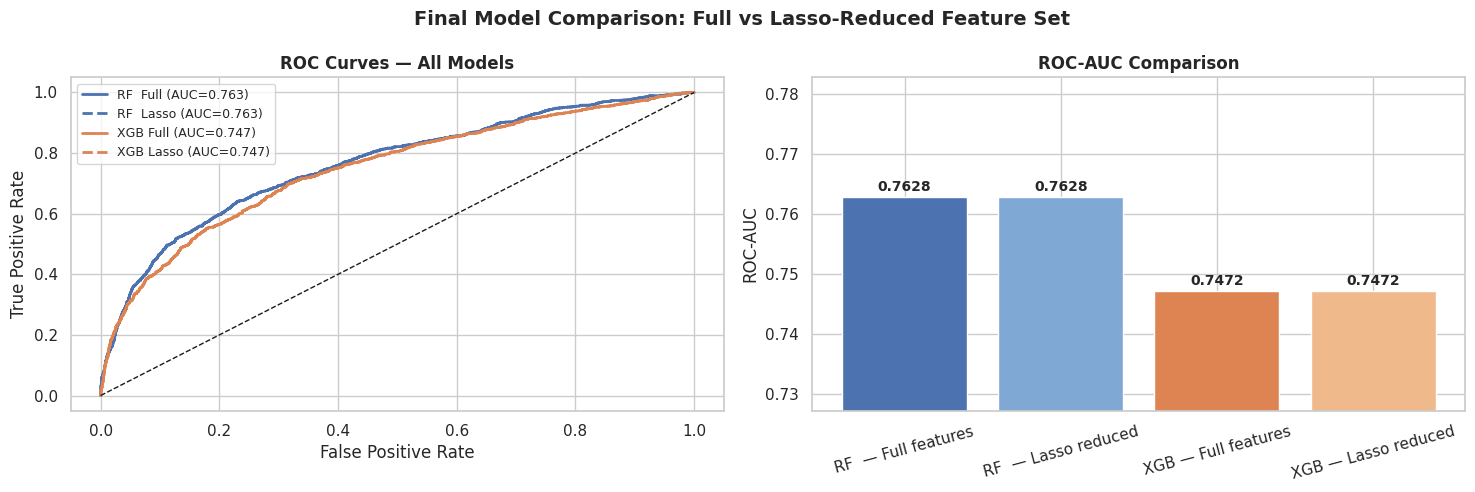

In [24]:
all_results = pd.DataFrame([
    metrics(y_test, y_pred,         y_proba,         "RF  — Full features"),
    metrics(y_test, y_pred_rf_red,  y_proba_rf_red,  "RF  — Lasso reduced"),
    metrics(y_test, y_pred_xgb,     y_proba_xgb,     "XGB — Full features"),
    metrics(y_test, y_pred_xgb_red, y_proba_xgb_red, "XGB — Lasso reduced"),
]).set_index("Model")

display(all_results.style.highlight_max(axis=0, color="#c6efce").format("{:.4f}"))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overlaid ROC curves — all 4 models
pairs = [
    (y_proba,         "#4C72B0", "-",  "RF  Full"),
    (y_proba_rf_red,  "#4C72B0", "--", "RF  Lasso"),
    (y_proba_xgb,     "#DD8452", "-",  "XGB Full"),
    (y_proba_xgb_red, "#DD8452", "--", "XGB Lasso"),
]
for proba, color, ls, label in pairs:
    fpr_, tpr_, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr_, tpr_, lw=2, color=color, linestyle=ls,
                 label=f"{label} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — All Models", fontweight="bold")
axes[0].legend(fontsize=9)

# Bar chart of ROC-AUC
auc_vals = all_results["ROC-AUC"]
bar_colors = ["#4C72B0", "#7fa8d4", "#DD8452", "#f0b98b"]
bars = axes[1].bar(auc_vals.index, auc_vals.values, color=bar_colors, edgecolor="white")
for bar, val in zip(bars, auc_vals.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylim(auc_vals.min() - 0.02, auc_vals.max() + 0.02)
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("ROC-AUC Comparison", fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Final Model Comparison: Full vs Lasso-Reduced Feature Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

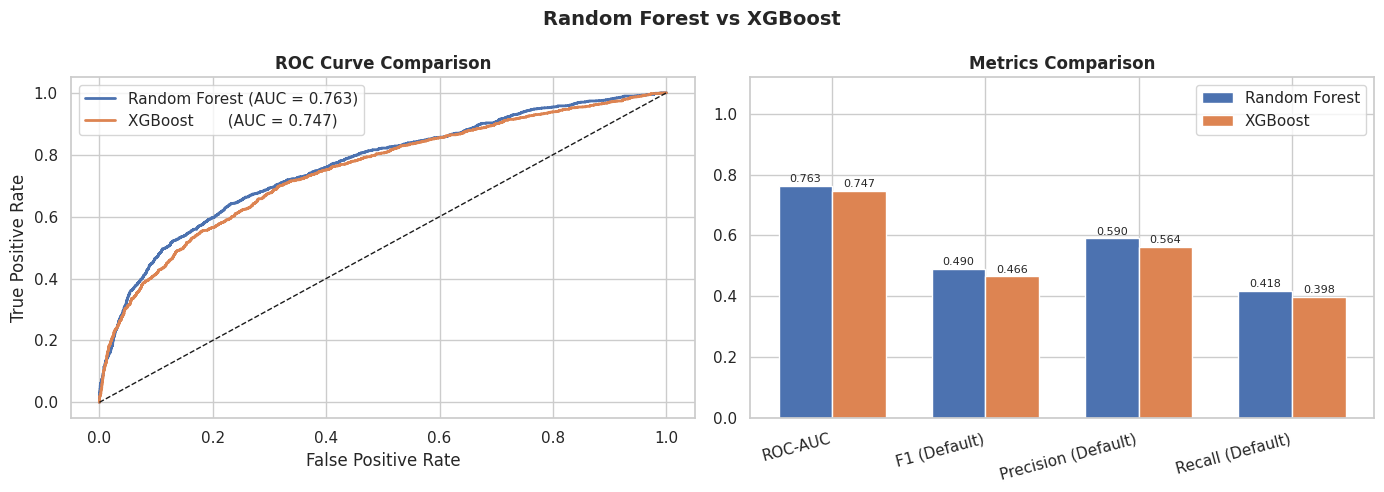

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC curves side by side ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba)
auc_rf  = roc_auc_score(y_test, y_proba)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

axes[0].plot(fpr_rf,  tpr_rf,  lw=2, color="#4C72B0", label=f"Random Forest (AUC = {auc_rf:.3f})")
axes[0].plot(fpr_xgb, tpr_xgb, lw=2, color="#DD8452", label=f"XGBoost       (AUC = {auc_xgb:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Comparison", fontweight="bold")
axes[0].legend()

# --- Metrics bar chart ---
metrics_plot = results[["ROC-AUC", "F1 (Default)", "Precision (Default)", "Recall (Default)"]].T
x = np.arange(len(metrics_plot))
w = 0.35
bars1 = axes[1].bar(x - w/2, metrics_plot["Random Forest"], w, label="Random Forest", color="#4C72B0", edgecolor="white")
bars2 = axes[1].bar(x + w/2, metrics_plot["XGBoost"],       w, label="XGBoost",       color="#DD8452", edgecolor="white")
for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_plot.index, rotation=15, ha="right")
axes[1].set_ylim(0, 1.12)
axes[1].set_title("Metrics Comparison", fontweight="bold")
axes[1].legend()

plt.suptitle("Random Forest vs XGBoost", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

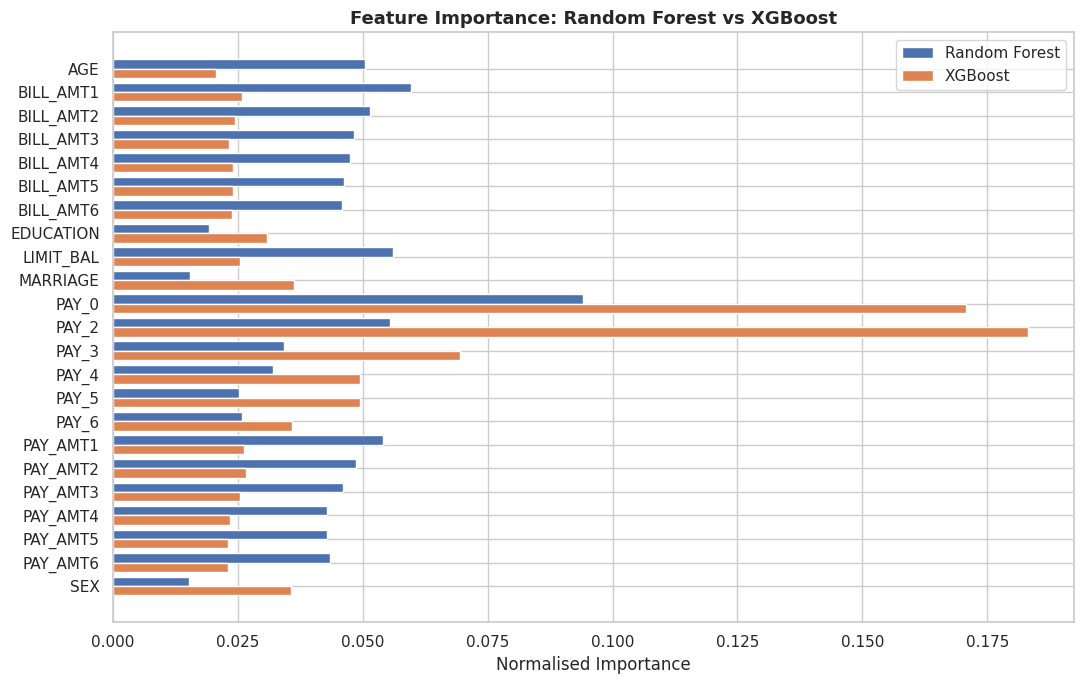

In [26]:
# Side-by-side feature importance: which features both models agree on?
imp_rf  = pd.Series(best_rf.feature_importances_,  index=feature_cols).sort_values(ascending=False)
imp_xgb = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

imp_df = pd.DataFrame({"Random Forest": imp_rf, "XGBoost": imp_xgb})
imp_df = imp_df.div(imp_df.sum())  # normalise so both sum to 1

fig, ax = plt.subplots(figsize=(11, 7))
x = np.arange(len(imp_df))
w = 0.4
ax.barh(x + w/2, imp_df["Random Forest"].values[::-1], w, label="Random Forest", color="#4C72B0", edgecolor="white")
ax.barh(x - w/2, imp_df["XGBoost"].values[::-1],       w, label="XGBoost",       color="#DD8452", edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(imp_df.index[::-1])
ax.set_xlabel("Normalised Importance")
ax.set_title("Feature Importance: Random Forest vs XGBoost", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("plot_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()